# SAM Model finetuning 
## Author : Dhruv Panchal 
## Guide : Prof. Arpit Rana 


In [2]:
import torch
import torchvision
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
import os

#### Data Structuring 

In [3]:
#### this my paths in which i have images : C:\Users\dhruv\Documents\DA-IICT\Arpit_rana\SAM_Model\Codes\Notebook\images_1024\images

In [4]:
os.chdir("../")

In [5]:
### create image path lists
## images folder 
images_path = os.path.join(os.getcwd(),"Arial_images_1024_1024/images")
print(f"number of images are: {len(os.listdir(images_path))}")

## creating images list in which we are storing our images path
images = []

for i in range(len(os.listdir(images_path))):
    images.append(f"{os.path.join(images_path,os.listdir(images_path)[i])}")


# print(images)

number of images are: 16


#### Demo show on first image

In [6]:
img_1 = images[0]
img_1

'/home/student/Documents/Arpit_sir/SOLAR/CodeFiles/dhruv_git/Solar_Rooftop_Detection/Arial_images_1024_1024/images/0.jpg'

In [7]:
im = cv2.imread(img_1)

cv2.imshow("Demo-Image",im)
cv2.waitKey(10000)
cv2.destroyAllWindows()

In [8]:
cv2.destroyAllWindows()

In [9]:
### Working fine

In [10]:
## the same way lets create list of masks
masks_path = os.path.join(os.getcwd(),"Arial_images_1024_1024/masks")
print(f"number of masks are: {len(os.listdir(masks_path))}")

## creating masks list in which we are storing our masks path
masks = []

for i in range(len(os.listdir(masks_path))):
    masks.append(f"{os.path.join(masks_path,os.listdir(masks_path)[i])}")

print(masks)

number of masks are: 16
['/home/student/Documents/Arpit_sir/SOLAR/CodeFiles/dhruv_git/Solar_Rooftop_Detection/Arial_images_1024_1024/masks/0.jpg', '/home/student/Documents/Arpit_sir/SOLAR/CodeFiles/dhruv_git/Solar_Rooftop_Detection/Arial_images_1024_1024/masks/7.jpg', '/home/student/Documents/Arpit_sir/SOLAR/CodeFiles/dhruv_git/Solar_Rooftop_Detection/Arial_images_1024_1024/masks/6.jpg', '/home/student/Documents/Arpit_sir/SOLAR/CodeFiles/dhruv_git/Solar_Rooftop_Detection/Arial_images_1024_1024/masks/10.jpg', '/home/student/Documents/Arpit_sir/SOLAR/CodeFiles/dhruv_git/Solar_Rooftop_Detection/Arial_images_1024_1024/masks/4.jpg', '/home/student/Documents/Arpit_sir/SOLAR/CodeFiles/dhruv_git/Solar_Rooftop_Detection/Arial_images_1024_1024/masks/15.jpg', '/home/student/Documents/Arpit_sir/SOLAR/CodeFiles/dhruv_git/Solar_Rooftop_Detection/Arial_images_1024_1024/masks/1.jpg', '/home/student/Documents/Arpit_sir/SOLAR/CodeFiles/dhruv_git/Solar_Rooftop_Detection/Arial_images_1024_1024/masks/13.jp

In [11]:
### now lets create dictionary for storing boundng boxs cordinates 

## this dictionary contain image_path as key and as vlaues it store the list of bounding box cordinates.
bounding_boxes = {}

### example { 'path_to_image1.jpg': [(x1, y1, w1, h1), (x2, y2, w2, h2), ... ] }


def bounding_box(mask_image):
    """
    Arguments: 
    mask_image : it takes mask image as input.

    Return: list of bounding box cordinates.
    """
    
    # Ensure the mask is binary
    _, binary_mask = cv2.threshold(mask_image, 128, 255, cv2.THRESH_BINARY)
    
    ## to see the mask image after thresholding
    # cv2.imshow("mask_images_after_threshold",binary_mask)
    # cv2.waitKey(0)
    # cv2.destroyAllWindows()

    # Find contours
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    print(f"total number of rooftops in the image is : {len(contours)}")

    # List to store bounding boxes
    bounding_boxes = []

    # Loop through contours and get bounding boxes
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        bounding_boxes.append((x, y, x+w, y+h))

    return bounding_boxes

### 
for i in range(len(images)):
    mask_img = cv2.imread(masks[i], cv2.IMREAD_GRAYSCALE)
    bounding_boxes[images[i]] = bounding_box(mask_img)

# bounding_boxes

total number of rooftops in the image is : 45
total number of rooftops in the image is : 44
total number of rooftops in the image is : 48
total number of rooftops in the image is : 148
total number of rooftops in the image is : 124
total number of rooftops in the image is : 129
total number of rooftops in the image is : 55
total number of rooftops in the image is : 155
total number of rooftops in the image is : 96
total number of rooftops in the image is : 166
total number of rooftops in the image is : 163
total number of rooftops in the image is : 161
total number of rooftops in the image is : 50
total number of rooftops in the image is : 165
total number of rooftops in the image is : 179
total number of rooftops in the image is : 60


In [17]:
## Demo on one imagedatetime.now().strftime("%Y_%m_%d")
def plot_bounding_box(image, bounding_box_cordinates):
    """take images and bounding box cordinates and plot bounding box
    
    Arguments:
        image = original image
        bounding_box_cordinates = list of bounding box cordinates

    Return: An image on which bounding box is drawn.
    """
    
    demo = image.copy()

    for bb in bounding_box_cordinates:
        x,y,w,h = bb
        cv2.rectangle(demo, (x,y),(w,h), (255,0,0), 2)

    cv2.imshow("draw_bounding_box", demo)
    cv2.waitKey(10000)
    cv2.destroyAllWinddatetime.now().strftime("%Y_%m_%d")age",demo_im)
cv2.waitKey(0)
cv2.destroyAllWindows()

bb = bounding_boxes[im]
bb_image = plot_bounding_box(demo_im, bb)

In [30]:
## now create custom Datset
from torch.utils.data import Dataset, DataLoader

class my_dataset(Dataset):
    def __init__(self, image_paths, mask_paths):
        self.image_paths = image_paths
        self.mask_paths = mask_paths

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = cv2.imread(image_path)
        image = cv2.resize(image, (1024, 1024))
        
        # Convert image to RGB format
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        ## Load and preprocess the binary mask(1 channel)
        mask_path = self.mask_paths[idx]
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (1024,1024))

        ## Convert image and mask to torch tensor 
        image = torch.tensor(image).permute(2,0,1).float()/255.0
        mask = torch.tensor(mask)

        return image, mask

In [31]:
len(images), len(masks)

(16, 16)

In [32]:
dataset = my_dataset(images, masks)

In [33]:
### Now implement Data Loader
data_loader = DataLoader(dataset=dataset, batch_size=4, shuffle=True)
data_loader

In [34]:
data_loader.dataset[0][0].shape, data_loader.dataset[0][1].shape

(torch.Size([3, 1024, 1024]), torch.Size([1024, 1024]))

In [35]:
sample_image, sample_mask = dataset[0]
print(f"image shape : {sample_image.shape}, sample mask shape : {sample_mask.shape}")

image shape : torch.Size([3, 1024, 1024]), sample mask shape : torch.Size([1024, 1024])


In [36]:
# , no of rooftops in the image is :{len(sample_box_cordinates)}

In [37]:
from segment_anything import build_sam_vit_b

In [42]:
## to download Model 
# wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth -O sam_vit_b.pth

In [41]:
## initiallize the SAM model with vit-b configuration
model = build_sam_vit_b("/home/student/Documents/Arpit_sir/SOLAR/CodeFiles/dhruv_git/sam_vit_b.pth")
model

/home/student/Documents/Arpit_sir/solar_vnv/lib/python3.10/site-packages/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.

Sam(
  (image_encoder): ImageEncoderViT(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): Linear(in_features=3072, out_features=768, bias=True)
          (act): GELU(approximate='none')
        )
      )
    )
    (neck): Sequential(
      (0): Conv2d(768, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): LayerNorm2d()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (3): LayerNorm2d()
    )


In [43]:
### we are fine tuning our model.
### for that we freeze the image encoder and prompt encoder.
### we allow only mask decoder to fine tune.

In [44]:
## select device 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Sam(
  (image_encoder): ImageEncoderViT(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): Linear(in_features=3072, out_features=768, bias=True)
          (act): GELU(approximate='none')
        )
      )
    )
    (neck): Sequential(
      (0): Conv2d(768, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): LayerNorm2d()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (3): LayerNorm2d()
    )


In [47]:
from torch.nn import functional as F

In [48]:
def generate_isolated_mask(mask, box):
    x1, y1, x2, y2 = box
    # print(x1, y1, x2, y2)

    isloated_mask = torch.zeros_like(mask)
    
    # print(mask[y1: y2, x1:x2].shape)
    
    isloated_mask[y1: y2, x1:x2] = mask[y1: y2, x1:x2]
    
    # print(np.unique(isloated_mask.numpy()))
    
    # cv2.imshow("new_mask",isloated_mask.numpy())
    # cv2.waitKey(0)
    # cv2.destroyAllWindows()
    
    # print(isloated_mask.shape)

    return isloated_mask

In [49]:
m = data_loader.dataset[0][1]
print(m.shape)
b = bounding_box(m.numpy())
len(b)

torch.Size([1024, 1024])
total number of rooftops in the image is : 45


45

In [50]:
b[1]

(298, 1007, 337, 1024)

In [51]:
m[298:337, 1007:1024]

tensor([[  0,   0,   0,   1,   0,   0,   0,   2,   0, 255, 255, 255, 251, 252,
         255, 254,   0],
        [  0,   0,   0,   1,   0,   1,   3,   0, 253, 254, 255, 252, 255, 255,
         255, 255, 254],
        [  0,   5,   0,   0,   0,   0,   0,   1, 255, 255, 255, 255, 255, 255,
         254, 254, 255],
        [  0,   0,   0,   2,   1,   0,   0, 255, 255, 255, 250, 255, 254, 253,
         255, 255, 254],
        [  0,   1,   3,   0,   0,   1,   3, 255, 254, 255, 255, 252, 255, 255,
         255, 254, 255],
        [  0,   1,   0,   0,   2,   0, 255, 254, 255, 255, 252, 255, 255, 255,
         255, 253, 255],
        [  0,   0,   1,   1,   0,   0, 255, 254, 255, 255, 255, 255, 255, 255,
         255, 255, 255],
        [  0,   0,   0,   0,   5, 255, 254, 255, 254, 255, 255, 255, 255, 255,
         255, 255, 255],
        [  0,   2,   1,   1,   0, 253, 255, 252, 255, 255, 255, 255, 255, 255,
         255, 255, 255],
        [  0,   1,   0,   0, 255, 253, 255, 255, 255, 255, 255, 

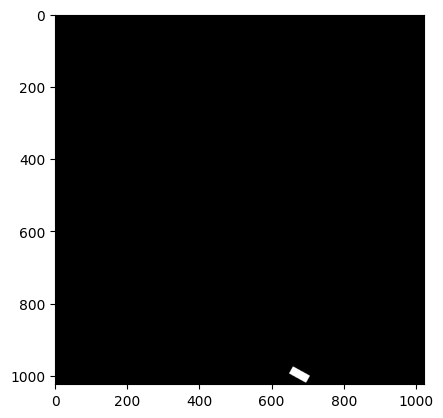

In [52]:
out = generate_isolgenerate_isolated_masksated_mask(m, b[2])
out = out.squeeze(-1)
plt.imshow(out, cmap="gray")

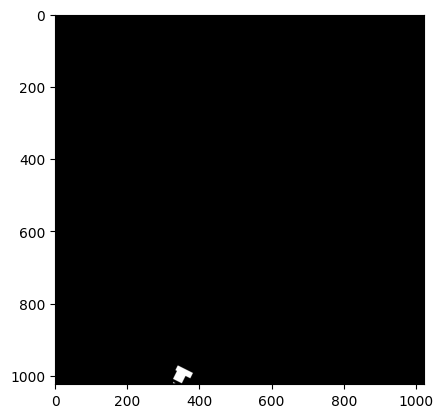

In [53]:
out = generate_isolated_mask(m, b[3])
out = out.squeeze(-1)
plt.imshow(out, cmap="gray")

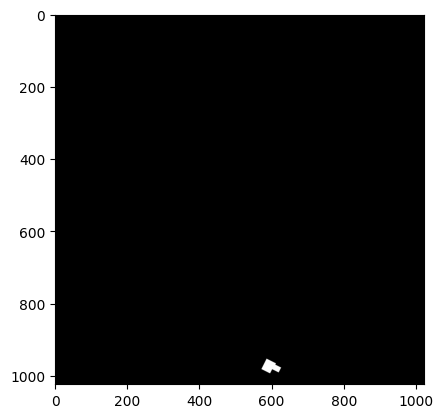

In [54]:
out = generate_isolated_mask(m, b[4])
out = out.squeeze(-1)
plt.imshow(out, cmap="gray")

In [55]:
cv2.destroyAllWindows()

In [ ]:
from torch.optim import Adam
from torch import nn

In [1]:
optimizer = Adam(model.mask_decoder.parameters(),lr=0.001)
criterion = nn.CrossEntropyLoss()

NameError: name 'Adam' is not defined

# Training 

In [56]:
## lets define training loop

### number of epochs
num_epochs = 10

torch.Size([3, 1024, 1024]) torch.Size([1024, 1024])
total number of rooftops in the image is : 161
isolated mask shape :  torch.Size([1, 1024, 1024])
Upsampled mask shape :  torch.Size([1, 1, 1024, 1024])
Unique values this tensor contain is :  tensor([-46.3576, -45.7059, -45.5897,  ...,  10.3837,  10.4496,  10.8589],
       grad_fn=<Unique2Backward0>)
runing loss: 0.0


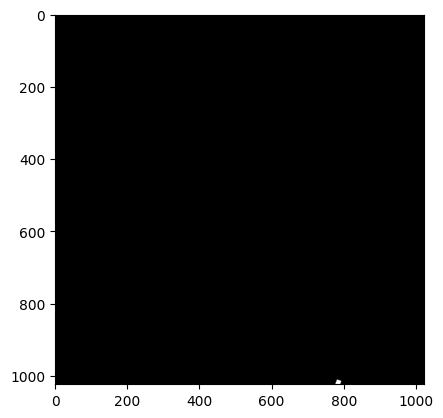

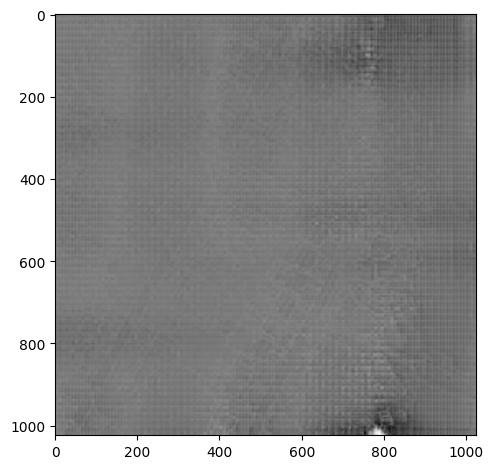

In [ ]:
for epoch in range(num_epochs):
    # Train the model
    model.train()


    running_loss = 0

    for img, mask in data_loader:
        
        image_ = img.to(device)
        mask_ = mask.to(device)
        
        optimizer.zero_grad()

        # print(f"images size : {image_.shape}, masks size : {mask_.shape}")


        for i, (image, mask) in enumerate(zip(image_, mask_)):
            print(image.shape, mask.shape)

            ## getting the bounding box coordinates from masks 
            # print(mask.numpy())
            ## here we have to pass numpy array
            # print(mask.numpy().astype(np.uint8))
            bounding_box_corr = bounding_box(mask.numpy().astype(np.uint8))
            # print(bounding_box_corr)


            for coordinates in bounding_box_corr:
                # print(f"points are : {coordinates}")
                one_isolated_mask = generate_isolated_mask(mask, coordinates)
                one_isolated_mask = one_isolated_mask.unsqueeze(0)
                print("isolated mask shape : ",one_isolated_mask.shape)

                sparse_embeddings, dense_embeddings = model.prompt_encoder(
                    points = None,
                    boxes = torch.tensor([coordinates]).unsqueeze(0).to(device),
                    masks = None)

                low_res_mask, _ = model.mask_decoder(
                    image_embeddings = model.image_encoder(image.unsqueeze(0)),
                    image_pe = model.prompt_encoder.get_dense_pe(),
                    sparse_prompt_embeddings = sparse_embeddings,
                    dense_prompt_embeddings = dense_embeddings,
                    multimask_output = False
                )

                upsampled_masks = F.interpolate(low_res_mask, size = (1024, 1024), mode="bilinear", align_corners=False)

                ## calculate the loss
                print("Upsampled mask shape : ",upsampled_masks.shape)
                print("Unique values this tensor contain is : ", torch.unique(upsampled_masks))
                
                # print(upsampled_masks)
                loss = criterion(upsampled_masks, one_isolated_mask.unsqueeze(0).float())
                loss.backward()
                optimizer.step()

                running_loss += loss.item()
                print(f"runing loss: {running_loss}")



                ## to see the output and actual masks
                # copy_up_sampled = upsampled_masks.clone()
                # plt.imshow(one_isolated_mask.squeeze(0).numpy(), cmap="gray")
                # plt.show()
                # plt.imshow(copy_up_sampled.squeeze(0).squeeze(0).detach().numpy(),cmap="gray")
                # plt.tight_layout()
                # plt.show()

                break 

    
    # print(f"epoch {epoch}, loss: {running_loss / len(data_loader)}")
            break
        break


        
    break      
    


In [40]:
data_loader

In [36]:
data_loader

In [41]:
data_loader.dataset[0][1]

tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]], dtype=torch.uint8)

In [34]:
data_loader.dataset[0][2]

[(578, 1023, 580, 1024),
 (298, 1007, 337, 1024),
 (648, 975, 705, 1020),
 (327, 973, 382, 1022),
 (571, 954, 626, 994),
 (365, 926, 424, 977),
 (894, 923, 952, 988),
 (135, 905, 227, 1003),
 (346, 892, 373, 918),
 (59, 886, 122, 972),
 (321, 877, 347, 896),
 (568, 874, 649, 934),
 (725, 868, 860, 1018),
 (676, 838, 759, 906),
 (359, 833, 458, 928),
 (436, 819, 486, 874),
 (147, 814, 223, 874),
 (0, 806, 2, 810),
 (413, 805, 451, 826),
 (438, 752, 517, 810),
 (172, 751, 246, 819),
 (458, 686, 533, 754),
 (262, 677, 367, 797),
 (396, 658, 443, 711),
 (0, 620, 58, 699),
 (289, 584, 362, 684),
 (46, 543, 65, 567),
 (79, 476, 159, 575),
 (0, 456, 33, 526),
 (1016, 426, 1024, 444),
 (737, 306, 858, 407),
 (969, 296, 1024, 409),
 (847, 261, 965, 436),
 (662, 182, 734, 268),
 (970, 103, 1024, 165),
 (542, 100, 611, 185),
 (858, 43, 918, 117),
 (284, 26, 401, 127),
 (789, 21, 837, 75),
 (991, 0, 1001, 5),
 (809, 0, 853, 27),
 (695, 0, 750, 30),
 (335, 0, 455, 50),
 (195, 0, 230, 15),
 (105, 0,

In [55]:
next(iter(data_loader))

RuntimeError: each element in list of batch should be of equal size